Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter initial window size: 3
Enter maximum window size: 7


/tmp/ipython-input-2483229097.py:36: RuntimeWarning: overflow encountered in scalar subtract
  B2 = img[i, j] - zmax


PSNR Median: 24.742750406843037
PSNR Adaptive Median: 24.78011266254564


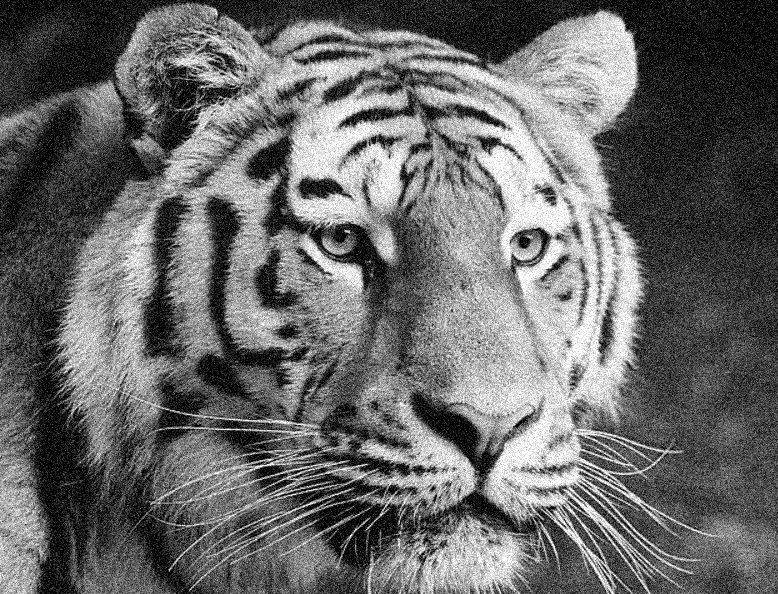

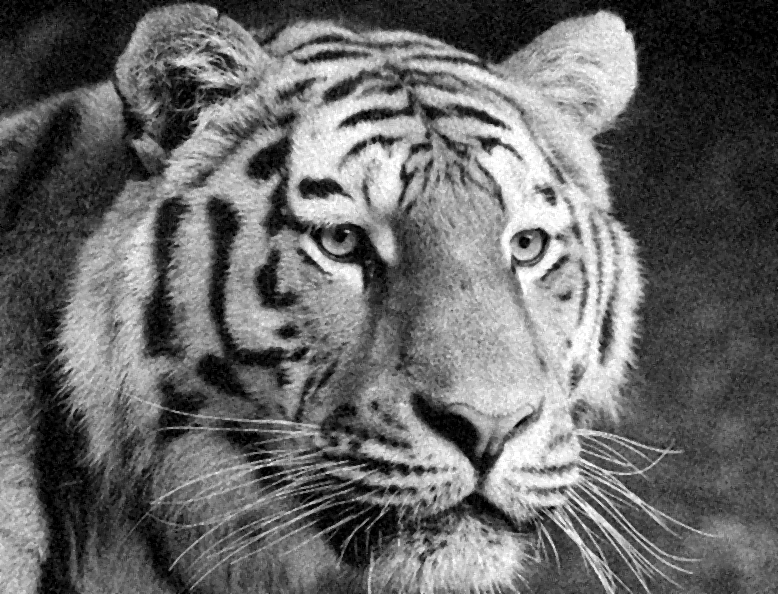

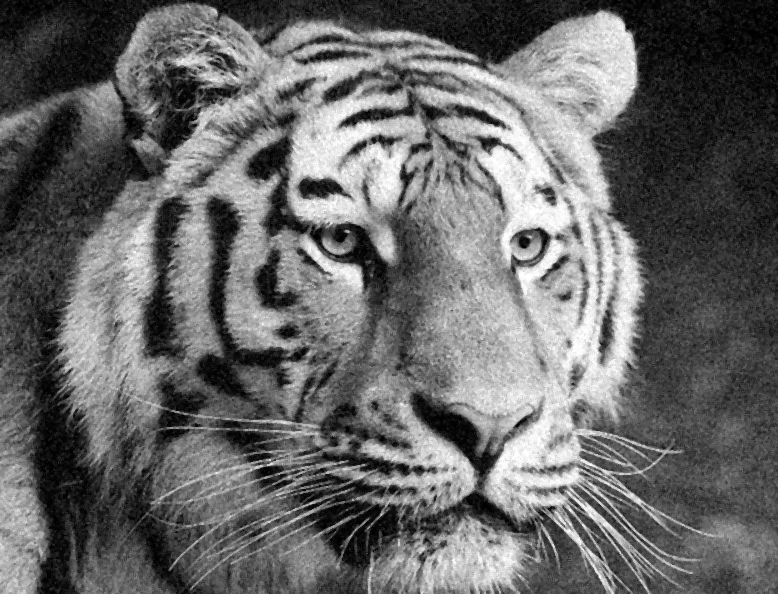

In [2]:
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from google.colab.patches import cv2_imshow
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/Image Processing Lab Files/EST Lab File (.ipynb)/Tiger.png'
img = cv2.imread(path, 0)

initial_size = int(input("Enter initial window size: "))
Smax = int(input("Enter maximum window size: "))

def adaptive_median_filter(img, Smax, S):
    m, n = img.shape
    out = img.copy()
    for i in range(m):
        for j in range(n):
            k = S
            while True:
                r = k // 2
                x1, x2 = max(0, i-r), min(m, i+r+1)
                y1, y2 = max(0, j-r), min(n, j+r+1)

                window = img[x1:x2, y1:y2]
                zmin = window.min()
                zmax = window.max()
                zmed = np.median(window)

                A1 = zmed - zmin
                A2 = zmed - zmax

                if A1 > 0 and A2 < 0:
                    B1 = img[i, j] - zmin
                    B2 = img[i, j] - zmax

                    if B1 > 0 and B2 < 0:
                        out[i, j] = img[i, j]
                    else:
                        out[i, j] = zmed
                    break
                else:
                    k += 2
                    if k > Smax:
                        out[i, j] = zmed
                        break
    return out

noisy = img.astype(np.float32) / 255
noisy = noisy + 0.1 * np.random.randn(*img.shape)
noisy = np.clip(noisy, 0, 1)
noisy = (noisy * 255).astype(np.uint8)

median_img = cv2.medianBlur(noisy, initial_size)
adaptive_img = adaptive_median_filter(noisy, Smax, initial_size)

psnr_median = psnr(img, median_img)
psnr_adaptive = psnr(img, adaptive_img)

print("PSNR Median:", psnr_median)
print("PSNR Adaptive Median:", psnr_adaptive)

cv2_imshow(noisy)
cv2_imshow(median_img)
cv2_imshow(adaptive_img)
